

# Cross Validation
### OPIM 5512 — Applied Data Science · Module2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-notebooks/blob/main/Module2/1_CrossValidation.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# CV strategies (from scratch)
**OPIM 5512: Data Science Using Python - University of Connecticut**

-----------------------------------------------
Cross-validation is an essential part of machine learning! Let's review some common validation strategies...
* simple holdout
* k-fold cross-validation
* 10x repeated k-fold cross-validation
* leave one observation cross-validation (LOOCV)
* leave one group out cross-validation (LOGOCV)

<center>

![k fold example](https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_002.png)

</center>

**Figure 1:** a simple k-fold validation- can you see why it's important to shuffle your data?!



You'll learn how to code these up using for loops (for complete clarity) and then you'll see the implementation with sklearn. Of course, these strategies work for any ML model and for both classification and regression problems. We will use a simple linear regression.

Pay particular attention to the plethora of error metrics that come out of the algorithm - even though most folks only report the average error across all folds, the distribution can be interesting!

Think about how you might be able to incorporate SMOTE or other sampling strategies into your validations.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# Data Prep
Let's see how many ways we can fit a simple linear regression on the California Housing dataset.

In [ ]:
# import modules we need for EDA and wrangling
import pandas as pd
import numpy as np

# these functions are useful for splitting and normalization
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# import other functions we'll need for regression modeling
from sklearn.linear_model import LinearRegression # LR

# regression error metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# CV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [ ]:
# we will use California Housing for this example
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [ ]:
ocean_proximity = pd.get_dummies(pd.Series(df['ocean_proximity']), drop_first=True)
df = pd.concat([df, ocean_proximity], axis=1)
df.drop('ocean_proximity',axis=1,inplace=True)

# X and y

In [ ]:
# the target variable is Y
# we know that this is 'median_house_value'
y = df['median_house_value']
print(y.shape) # a single column with 20640 rows

X = df.drop('median_house_value', axis=1)
print(X.shape)
print(y.shape)

(20433,)
(20433, 12)
(20433,)


## Data Splitting
It is ALWAYS a good idea to shuffle your dataframe before you do any modeling. You can shuffle before your split, DURING the split by setting `shuffle = True`, or both. Just don't shuffle the target variable!

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 1)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(16346, 12)
(16346,)
(4087, 12)
(4087,)


In [ ]:
# transfer it into dataframe
y_train=pd.DataFrame(y_train)
y_test=pd.DataFrame(y_test)

# 1) Random Holdout Sample
This one you already know!

In [ ]:
LR = LinearRegression()
LR = LR.fit(X_train, y_train)
train_preds = LR.predict(X_train)
test_preds = LR.predict(X_test)
train_MAE = mean_absolute_error(y_train, train_preds)
test_MAE = mean_absolute_error(y_test, test_preds)
print(train_MAE)
print(test_MAE)

49974.1475610123
49223.07280022244


So we see that on average, you are off by ~50k for house prices. Your results will be different due to randomness. But these results are subjective based on your single split! Set random_state = 1 or 2 or 3 and see how this changes.

# 2) k-fold

A simple k-fold split - a different sliver of the training partition is used each time.

![kfold](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

**Figure 2:** Diagram showing the folds within the training partition.

## By hand

In [ ]:
foldRange = [0,1,2,3,4]
resultDF5=[]

# don't forget to shuffle X_train and y_train first!
X_train, y_train = shuffle(X_train, y_train)

for i in foldRange:
  print(i)
  model_X_test = X_train[round(i*0.2*X_train.shape[0]) : round((i+1)*0.2*X_train.shape[0])]
  print(model_X_test.shape)
  model_y_test = y_train[round(i*0.2*y_train.shape[0]) : round((i+1)*0.2*y_train.shape[0])]
  print(model_y_test.shape)
  model_X_train = X_train[~X_train.isin(model_X_test)].dropna()
  print(model_X_train.shape)
  model_y_train = y_train[~y_train.isin(model_y_test)].dropna()
  print(model_y_train.shape)
  LR = LR.fit(model_X_train, model_y_train)
  test_preds = LR.predict(model_X_test) #all you care about are test preds
  test_MAE = mean_absolute_error(model_y_test, test_preds) # calculate MSE
  resultDF5.append([i,test_MAE])# append it

0
(3269, 12)
(3269, 1)
(13077, 12)
(13077, 1)
1
(3269, 12)
(3269, 1)
(13077, 12)
(13077, 1)
2
(3270, 12)
(3270, 1)
(13076, 12)
(13076, 1)
3
(3269, 12)
(3269, 1)
(13077, 12)
(13077, 1)
4
(3269, 12)
(3269, 1)
(13077, 12)
(13077, 1)


In [ ]:
print(model_X_train.shape)
print(model_y_train.shape)
print(model_X_test.shape)
print(model_y_test.shape)

(13077, 12)
(13077, 1)
(3269, 12)
(3269, 1)


In [ ]:
# first column is fold, second column is related MAE of that fold
pd.DataFrame(resultDF5)

,0,1
0,0,49813.191786
1,1,49041.204993
2,2,50416.035630
3,3,51078.472543
4,4,49916.170277


In [ ]:
# what's the mean(MAE)?
np.mean(pd.DataFrame(resultDF5).iloc[:,1])

np.float64(50053.015045899454)

With such limited datapoints, you probably don't need to make a boxplot or density plot... but you will soon!

## By code

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)
LR = LinearRegression()

MAE = cross_val_score(LR, X, y, scoring='neg_mean_absolute_error', cv=kf)
MAE

array([-58319.62266352, -54380.24008376, -54406.07391512, -55586.0188536 ,
       -47569.7556697 ])

In [ ]:
abs(np.mean(MAE))

np.float64(54052.342237140416)

# 3) 10x repeated k-fold
If you are fitting at 10x repeated 5-fold cross-validations, you are going to fit 50 models!

In [ ]:
# evaluate a logistic regression model using repeated k-fold cross-validation
from numpy import mean
from numpy import std
from sklearn.model_selection import RepeatedKFold
from sklearn.utils import shuffle

## By hand

In [ ]:
from sklearn.utils import shuffle

foldRange = np.arange(5)
repeatRange = np.arange(10)
resultDF = []

for a in repeatRange: # 0 - 9 (10x repeated)
  # make sure you shuffle between repetititions, otherwise you will just get the same folds!
  X_train, y_train = shuffle(X_train, y_train) # shuffles them together!
  for i in foldRange: # 0 - 4 (5 fold)
    model_X_test = X_train[round(i*0.2*X_train.shape[0]) : round((i+1)*0.2*X_train.shape[0])]
    model_y_test = y_train[round(i*0.2*y_train.shape[0]) : round((i+1)*0.2*y_train.shape[0])]
    model_X_train = X_train[~X_train.isin(model_X_test)].dropna()
    model_y_train = y_train[~y_train.isin(model_y_test)].dropna()
    LR = LR.fit(model_X_train, model_y_train)
    test_preds = LR.predict(model_X_test) #all you care about are test preds
    test_MAE = mean_absolute_error(model_y_test, test_preds) # calculate MSE
    resultDF.append([i,test_MAE])# append it

# we need three columns not all in one list, and we need to select
# rows in order after shuffling


In [ ]:
resultDF = pd.DataFrame(resultDF)
resultDF

,0,1
0,0,49819.719566
1,1,50198.640241
2,2,49258.865591
3,3,50922.695755
4,4,50128.719825
5,0,49724.259522
6,1,50796.300506
7,2,50107.502690
8,3,49378.318751
9,4,50274.574426


In [ ]:
# what's the mean(MAE)?
theMean = np.mean(pd.DataFrame(resultDF).iloc[:,1])
print(theMean)

50059.99931027919


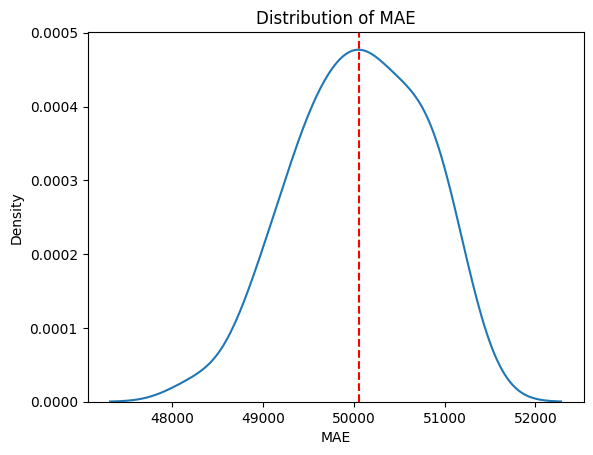

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(resultDF[1])
plt.axvline(theMean, color='red', linestyle="--")
plt.xlabel('MAE')
plt.title('Distribution of MAE')
plt.show()

**Figure 3:** Density plot of MAE distribution.

## By code

In [ ]:
# prepare the cross-validation procedure
cv = RepeatedKFold(n_splits=5, n_repeats=10,random_state=None)
# create model
LR = LinearRegression()
# evaluate model
MAE_repeatedCV = cross_val_score(LR, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
# report performance
MAE_repeatedCV

array([-48804.37483122, -50795.32481808, -50113.83466788, -49752.73433263,
       -50827.72075403, -49142.5818989 , -49775.621689  , -50061.29769609,
       -50516.59104723, -50716.13566239, -50402.83922597, -50438.12200774,
       -50892.66164252, -49612.13343002, -48916.77942579, -49653.91072128,
       -49897.08436991, -49602.7029104 , -50929.72641425, -50140.4081734 ,
       -51763.27845481, -49363.00556945, -49168.82642117, -50078.35956031,
       -50077.64792222, -51585.00260908, -49982.4502549 , -49553.15023273,
       -48721.45446093, -50399.07169541, -49868.93744013, -48705.33721725,
       -49784.49365842, -49887.56008826, -52005.09178702, -50584.19779794,
       -49059.6213724 , -50287.98546381, -49606.45284912, -50765.47816978,
       -49569.26121664, -52281.83909432, -50228.51229496, -48712.89625237,
       -49436.71877678, -50785.29804964, -49805.99136498, -49162.15543569,
       -50239.0575595 , -50341.98570235])

Note that ALL of the sklearn scores are such that you want to minimize the error, so smaller values are always better. This is why it happens to be `neg_mean_absolute_error`. You could always multiply by -1 to get it on the same scale afterwards...

In [ ]:
abs(mean(MAE_repeatedCV))

np.float64(50056.07408982204)

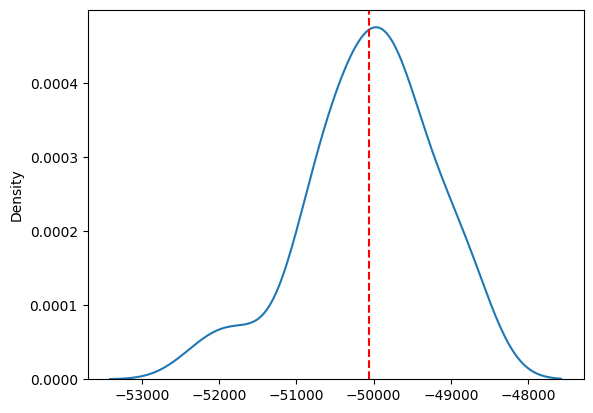

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# original output
sns.kdeplot(MAE_repeatedCV)
plt.axvline(np.mean(MAE_repeatedCV), color='red', linestyle="--")
plt.show()

**Figure 4:** Density plot of MAE distribution with negative naming convention on X axis.

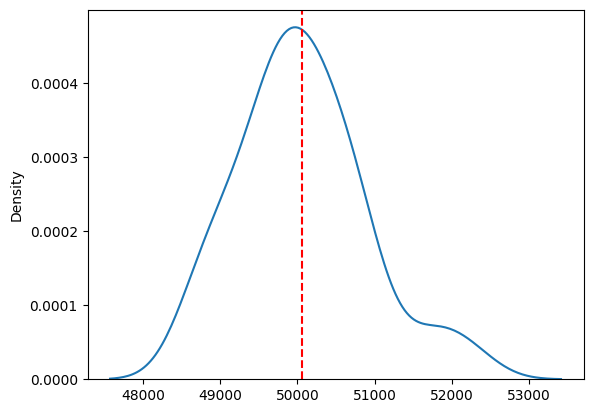

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# multiplying by the -1 is a bit goofy but necessary...
sns.kdeplot(-1*MAE_repeatedCV)
plt.axvline(-1*np.mean(MAE_repeatedCV), color='red', linestyle="--")
plt.show()

**Figure 5:** Density plot of MAE distribution (from repeated CV) with positive MAE on X axis.

# 4) Leave one observation out
This is just k-fold one steroids - where k is equal to the number of rows in the dataset. Get ready to fit 16346 models - and go get a cup of coffee while it does!

In [ ]:
print(X_train.shape)

(16346, 12)


## By Hand

In [ ]:
foldRange = range(X_train.shape[0])
resultDFLOO=[]
for i in foldRange:
  model_X_test = X_train[i:i+1]
  model_y_test = pd.DataFrame(y_train[i:i+1])
  model_X_train = X_train[~X_train.isin(model_X_test)].dropna()
  model_y_train = y_train[~y_train.isin(model_y_test)].dropna()
  LR = LR.fit(model_X_train, model_y_train)
  test_preds = LR.predict(model_X_test) #all you care about are test preds
  test_MAE = mean_absolute_error(model_y_test, test_preds) # calculate MSE
  resultDFLOO.append([i,test_MAE])# append it

KeyboardInterrupt: 

In [ ]:
pd.DataFrame(resultDFLOO)

In [ ]:
np.mean(pd.DataFrame(resultDFLOO))[1]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(resultDFLOO[1])
plt.axvline(np.mean(resultDFLOO[1]), color='red', linestyle="--")

## By code

In [ ]:
from sklearn.model_selection import LeaveOneOut

# create loocv procedure
cv = LeaveOneOut()
# create model
LR = LinearRegression()
# evaluate model
MAE_looCV = cross_val_score(LR, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
MAE_looCV

In [ ]:
abs(mean(MAE_looCV))

# 5) Leave one group out

Run a unique statement and return unique values of a categorical column, then fit a model with rows corresponding to each value as a test fold. Like this!

In [ ]:
# we will use California Housing for this example
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')

In [ ]:
print(df.shape)
df.dropna(inplace=True)
print(df.shape)

(20640, 10)
(20433, 10)


In [ ]:
theGroups = df['ocean_proximity'].unique()
theGroups

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# the target variable is Y
# we know that this is 'median_house_value'
y = df['median_house_value']
print(y.shape) # a single column with 20640 rows

X = df.drop('median_house_value', axis=1)
print(X.shape)
print(y.shape)

(20433,)
(20433, 9)
(20433,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 1)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(16346, 9)
(16346,)
(4087, 9)
(4087,)


## By hand

In [ ]:
resultDFgroups=[]
for i in theGroups:
  print(i)

  # prep the test fold
  X_test = df[df['ocean_proximity']==i]
  y_test = X_test['median_house_value']
  # get rid of the group variable!
  X_test.drop('ocean_proximity', inplace=True, axis=1)

  # prep the train fold
  X_train = df[df['ocean_proximity']!=i]
  y_train = X_train['median_house_value']
  # get rid of the group variable!
  X_train.drop('ocean_proximity', inplace=True, axis=1)

  # note below how the size of the training partition changes!
  print(X_train.shape, y_train.shape)

  # fit the models
  LR = LR.fit(X_train, y_train)
  test_preds = LR.predict(X_test) #all you care about are test preds
  test_MAE = mean_absolute_error(y_test, test_preds) # calculate MSE
  resultDFgroups.append([i,test_MAE])# append it

NEAR BAY
(18163, 9) (18163,)
<1H OCEAN
(11399, 9) (11399,)
INLAND
(13937, 9) (13937,)
NEAR OCEAN
(17805, 9) (17805,)
ISLAND
(20428, 9) (20428,)


/tmp/ipython-input-2361740370.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop('ocean_proximity', inplace=True, axis=1)
/tmp/ipython-input-2361740370.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop('ocean_proximity', inplace=True, axis=1)
/tmp/ipython-input-2361740370.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop('ocean_proximity', inplace=True, axis=1)
/tmp/ipython-input-2361740370.py

In [ ]:
resultDFgroups = pd.DataFrame(resultDFgroups)
resultDFgroups

,0,1
0,NEAR BAY,8.485145e-11
1,<1H OCEAN,2.939740e-11
2,INLAND,4.559458e-11
3,NEAR OCEAN,6.067866e-11
4,ISLAND,1.396984e-10


Again, given there are only a few categories, it may not make sense to make a boxplot here.

## [optional] By code
I actually think the sklearn implementation with getting different indices is confusing - feel free to read on your own and try to get it to run.


In [ ]:
# source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneGroupOut.html

import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
X = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
y = np.array([1, 2, 1, 2])
groups = np.array([1, 1, 2, 2])
logo = LeaveOneGroupOut()
logo.get_n_splits(X, y, groups)

logo.get_n_splits(groups=groups)  # 'groups' is always required

print(logo)

for train_index, test_index in logo.split(X, y, groups):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(X_train, X_test, y_train, y_test)


LeaveOneGroupOut()
TRAIN: [2 3] TEST: [0 1]
[[5 6]
 [7 8]] [[1 2]
 [3 4]] [1 2] [1 2]
TRAIN: [0 1] TEST: [2 3]
[[1 2]
 [3 4]] [[5 6]
 [7 8]] [1 2] [1 2]


I actually think coding your own might be a little easier than the code implementation - feel free to try to generalzie to our example if you would like... optional.

# Conclusion
You have refreshed yourself on five different types of validation strategies - with a focus on visualizing the error metrics of each fold, in addition to take the simple average of the error metrics. You've learned how to do this with code and by hand.

Now - go combine this with all of the preprocessing, sampling and modeling you've mastered and do something fantastic!

As you can tell, the code is getting longer - but that's okay. Just keep organized with lots of comments and build on our general modeling framework code.

There are many other versions of k-fold that you may want to review on your own. [See here](https://scikit-learn.org/stable/modules/cross_validation.html) for more.

![cross validation](https://scikit-learn.org/stable/_images/grid_search_workflow.png)
**Figure 6:** Hyperapareter tuning with cross-validation for model fitting workflow... *eventually*, you will use cross-validation to compare optimal hyperparameters! But for now, we will just evaluate a given model architecture multiple times using different cross-validation techniques.